In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/android-gaming-trends/android-games.csv


## Android Gaming Trends

## Description
The Android Gaming Trends dataset provides valuable insights into the performance and popularity of gaming applications on the Google Play Store. It includes detailed information about each app’s rank, total ratings, installs, average rating, growth trends, pricing, and category performance, along with a breakdown of user sentiment through star ratings (1★ to 5★).

By analyzing these attributes, one can uncover patterns in user engagement, monetization strategies (paid vs free games), market growth rates, and app category dominance. This dataset is ideal for data scientists, app developers, and business analysts aiming to identify what drives success in mobile gaming — such as how high-rated games grow over time, which categories dominate installs, and how paid apps compare to free ones in terms of performance and user satisfaction.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/android-gaming-trends/android-games.csv")

In [3]:
df.head()

,rank,title,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid
0,1,Garena Free Fire- World Series,86273129,500.0 M,4,2.1,6.9,0.0,GAME ACTION,63546766,4949507,3158756,2122183,12495915,False
1,2,PUBG MOBILE - Traverse,37276732,500.0 M,4,1.8,3.6,0.0,GAME ACTION,28339753,2164478,1253185,809821,4709492,False
2,3,Mobile Legends: Bang Bang,26663595,100.0 M,4,1.5,3.2,0.0,GAME ACTION,18777988,1812094,1050600,713912,4308998,False
3,4,Brawl Stars,17971552,100.0 M,4,1.4,4.4,0.0,GAME ACTION,13018610,1552950,774012,406184,2219794,False
4,5,Sniper 3D: Fun Free Online FPS Shooting Game,14464235,500.0 M,4,0.8,1.5,0.0,GAME ACTION,9827328,2124154,1047741,380670,1084340,False


In [4]:
df.tail()

,rank,title,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid
1725,96,زوايا - لعبة ستحرك زوايا عقلك,112408,1.0 M,4,0.9,1.8,0.0,GAME WORD,101036,3607,3237,1229,3297,False
1726,97,Bible Word Puzzle - Free Bible Word Games,111595,1.0 M,4,0.9,2.3,0.0,GAME WORD,88950,14856,4297,1385,2103,False
1727,98,Scrabble® GO - New Word Game,110723,10.0 M,4,0.9,1.9,0.0,GAME WORD,64184,18332,9385,6688,12132,False
1728,99,Word Nut: Word Puzzle Games & Crosswords,109530,5.0 M,4,1.9,4.1,0.0,GAME WORD,99987,4766,1469,953,2353,False
1729,100,Pinturillo 2,108917,10.0 M,3,1.1,2.5,0.0,GAME WORD,50813,16480,11825,6166,23631,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1730 entries, 0 to 1729
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              1730 non-null   int64  
 1   title             1730 non-null   object 
 2   total ratings     1730 non-null   int64  
 3   installs          1730 non-null   object 
 4   average rating    1730 non-null   int64  
 5   growth (30 days)  1730 non-null   float64
 6   growth (60 days)  1730 non-null   float64
 7   price             1730 non-null   float64
 8   category          1730 non-null   object 
 9   5 star ratings    1730 non-null   int64  
 10  4 star ratings    1730 non-null   int64  
 11  3 star ratings    1730 non-null   int64  
 12  2 star ratings    1730 non-null   int64  
 13  1 star ratings    1730 non-null   int64  
 14  paid              1730 non-null   bool   
dtypes: bool(1), float64(3), int64(8), object(3)
memory usage: 191.0+ KB


In [6]:
df.describe()

,rank,total ratings,average rating,growth (30 days),growth (60 days),price,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings
count,1730.000000,1.730000e+03,1730.000000,1730.000000,1730.000000,1730.000000,1.730000e+03,1.730000e+03,1.730000e+03,1.730000e+03,1.730000e+03
mean,50.386705,1.064332e+06,3.908092,321.735896,122.554971,0.010942,7.622315e+05,1.164366e+05,5.706307e+04,2.710336e+04,1.014950e+05
std,28.936742,3.429250e+06,0.290973,6018.914507,2253.891703,0.214987,2.538658e+06,3.021631e+05,1.495314e+05,8.154542e+04,4.083745e+05
min,1.000000,3.299300e+04,2.000000,0.000000,0.000000,0.000000,1.397500e+04,2.451000e+03,7.180000e+02,2.660000e+02,5.450000e+02
25%,25.000000,1.759992e+05,4.000000,0.100000,0.200000,0.000000,1.277300e+05,2.064300e+04,9.652500e+03,4.262250e+03,1.281200e+04
50%,50.000000,4.286065e+05,4.000000,0.500000,1.000000,0.000000,2.964340e+05,5.098050e+04,2.507800e+04,1.067550e+04,3.368600e+04
75%,75.000000,8.837970e+05,4.000000,1.700000,3.300000,0.000000,6.198358e+05,1.018140e+05,5.229500e+04,2.322875e+04,8.015725e+04
max,100.000000,8.627313e+07,4.000000,227105.700000,69441.400000,7.490000,6.354677e+07,5.404966e+06,3.158756e+06,2.122183e+06,1.249592e+07


In [7]:
df.isnull().sum()

rank                0
title               0
total ratings       0
installs            0
average rating      0
growth (30 days)    0
growth (60 days)    0
price               0
category            0
5 star ratings      0
4 star ratings      0
3 star ratings      0
2 star ratings      0
1 star ratings      0
paid                0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.describe().loc[["mean",'max','min']]

,rank,total ratings,average rating,growth (30 days),growth (60 days),price,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings
mean,50.386705,1.064332e+06,3.908092,321.735896,122.554971,0.010942,7.622315e+05,1.164366e+05,5.706307e+04,2.710336e+04,1.014950e+05
max,100.000000,8.627313e+07,4.000000,227105.700000,69441.400000,7.490000,6.354677e+07,5.404966e+06,3.158756e+06,2.122183e+06,1.249592e+07
min,1.000000,3.299300e+04,2.000000,0.000000,0.000000,0.000000,1.397500e+04,2.451000e+03,7.180000e+02,2.660000e+02,5.450000e+02


In [10]:
df.nunique()

rank                 100
title               1675
total ratings       1699
installs               9
average rating         3
growth (30 days)     186
growth (60 days)     206
price                  6
category              17
5 star ratings      1697
4 star ratings      1692
3 star ratings      1677
2 star ratings      1653
1 star ratings      1686
paid                   2
dtype: int64

In [11]:
df.dtypes

rank                  int64
title                object
total ratings         int64
installs             object
average rating        int64
growth (30 days)    float64
growth (60 days)    float64
price               float64
category             object
5 star ratings        int64
4 star ratings        int64
3 star ratings        int64
2 star ratings        int64
1 star ratings        int64
paid                   bool
dtype: object

In [12]:
df.shape

(1730, 15)

In [13]:
df.columns

Index(['rank', 'title', 'total ratings', 'installs', 'average rating',
       'growth (30 days)', 'growth (60 days)', 'price', 'category',
       '5 star ratings', '4 star ratings', '3 star ratings', '2 star ratings',
       '1 star ratings', 'paid'],
      dtype='object')

## Data visualizations

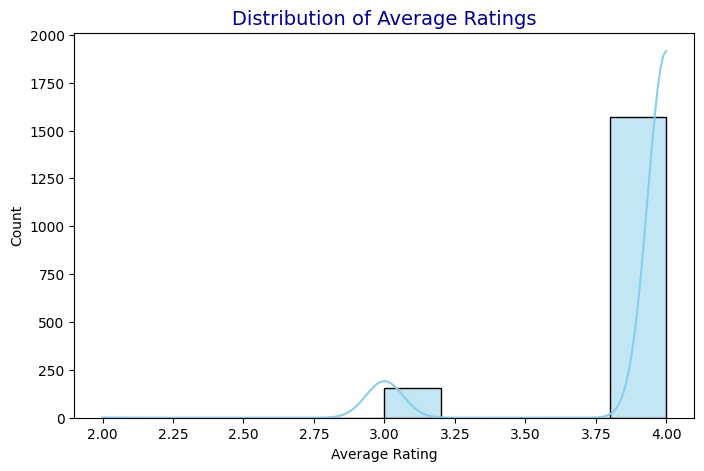

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['average rating'], kde=True, color='skyblue', bins=10)
plt.title('Distribution of Average Ratings', fontsize=14, color='darkblue')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.show()

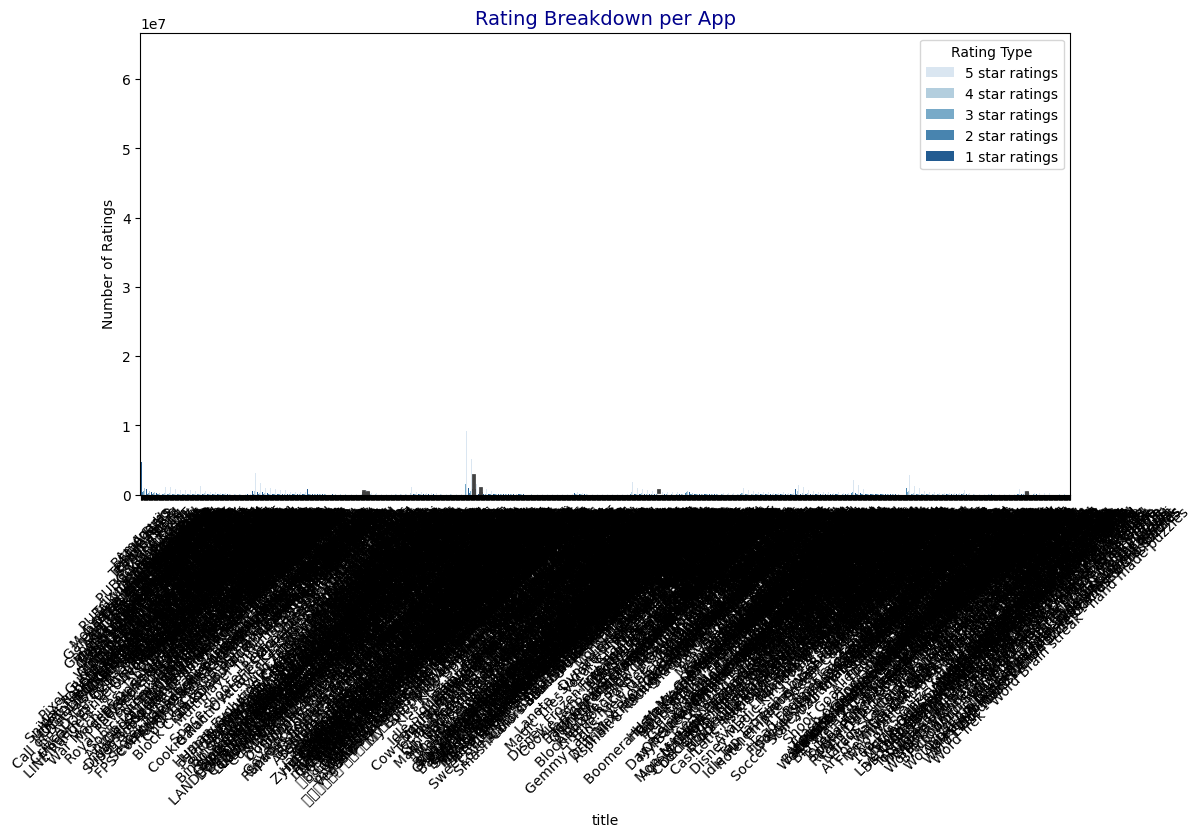

In [15]:
rating_cols = ['5 star ratings', '4 star ratings', '3 star ratings', '2 star ratings', '1 star ratings']
df_melted = df.melt(id_vars=['title'], value_vars=rating_cols, var_name='Rating Type', value_name='Count')

plt.figure(figsize=(12,6))
sns.barplot(x='title', y='Count', hue='Rating Type', data=df_melted, palette='Blues')
plt.title('Rating Breakdown per App', fontsize=14, color='darkblue')
plt.xticks(rotation=45)
plt.ylabel('Number of Ratings')
plt.show()

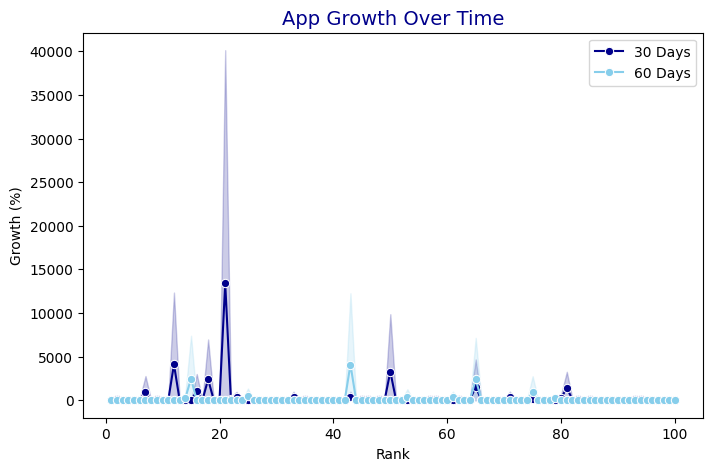

In [16]:
plt.figure(figsize=(8,5))
sns.lineplot(x='rank', y='growth (30 days)', data=df, label='30 Days', marker='o', color='darkblue')
sns.lineplot(x='rank', y='growth (60 days)', data=df, label='60 Days', marker='o', color='skyblue')
plt.title('App Growth Over Time', fontsize=14, color='darkblue')
plt.xlabel('Rank')
plt.ylabel('Growth (%)')
plt.legend()
plt.show()

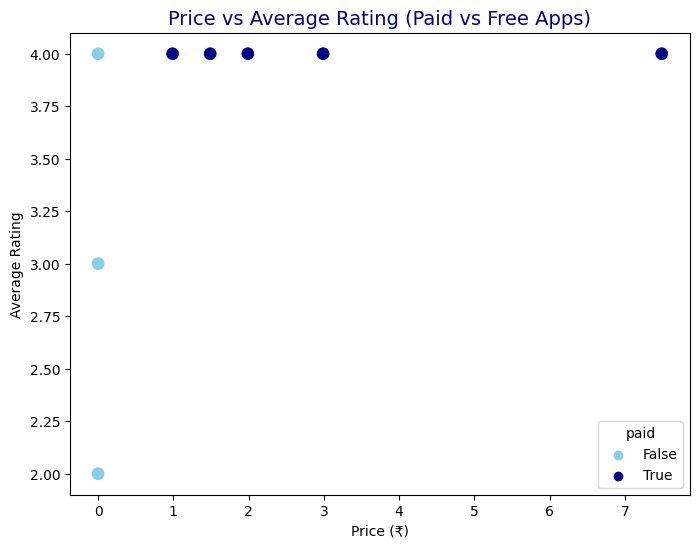

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='price', y='average rating', hue='paid', data=df, s=100, palette=['skyblue','darkblue'])
plt.title('Price vs Average Rating (Paid vs Free Apps)', fontsize=14, color='darkblue')
plt.xlabel('Price (₹)')
plt.ylabel('Average Rating')
plt.show()

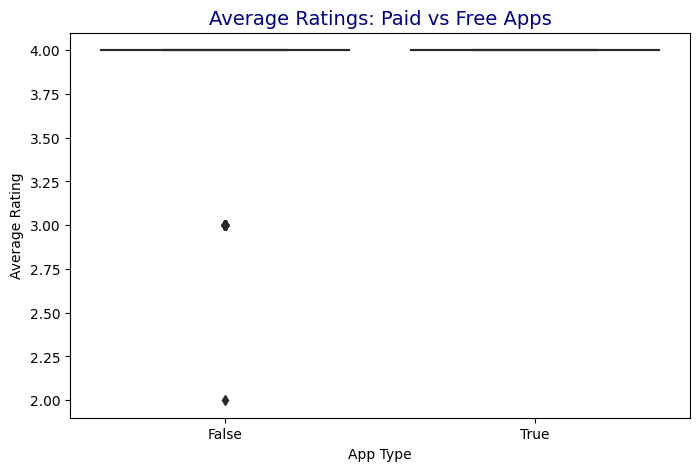

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='paid', y='average rating', data=df, palette=['skyblue', 'darkblue'])
plt.title('Average Ratings: Paid vs Free Apps', fontsize=14, color='darkblue')
plt.xlabel('App Type')
plt.ylabel('Average Rating')
plt.show()

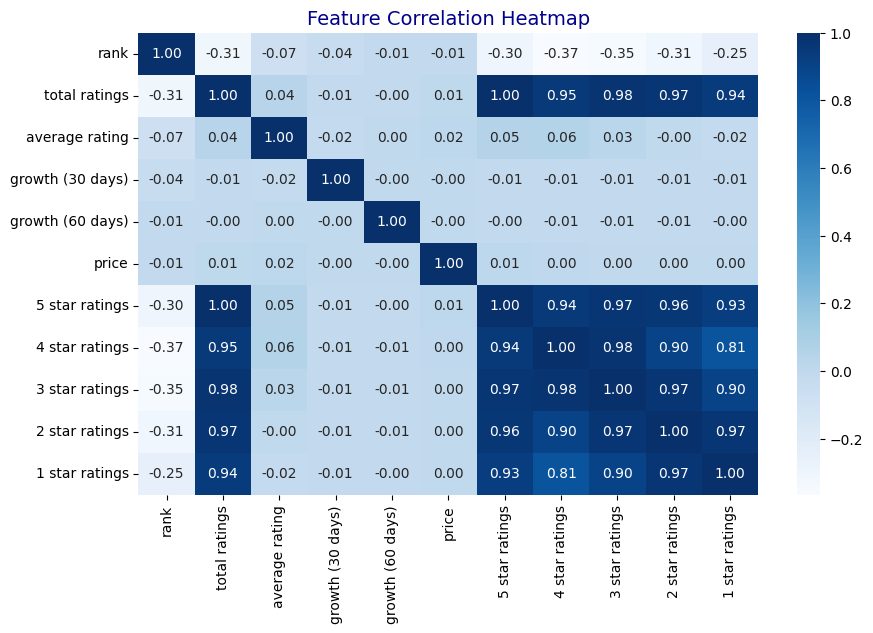

In [19]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, color='darkblue')
plt.show()

total ratings       float64
installs            float64
average rating      float64
growth (30 days)    float64
growth (60 days)    float64
price               float64
5 star ratings      float64
4 star ratings      float64
3 star ratings      float64
2 star ratings      float64
1 star ratings      float64
dtype: object


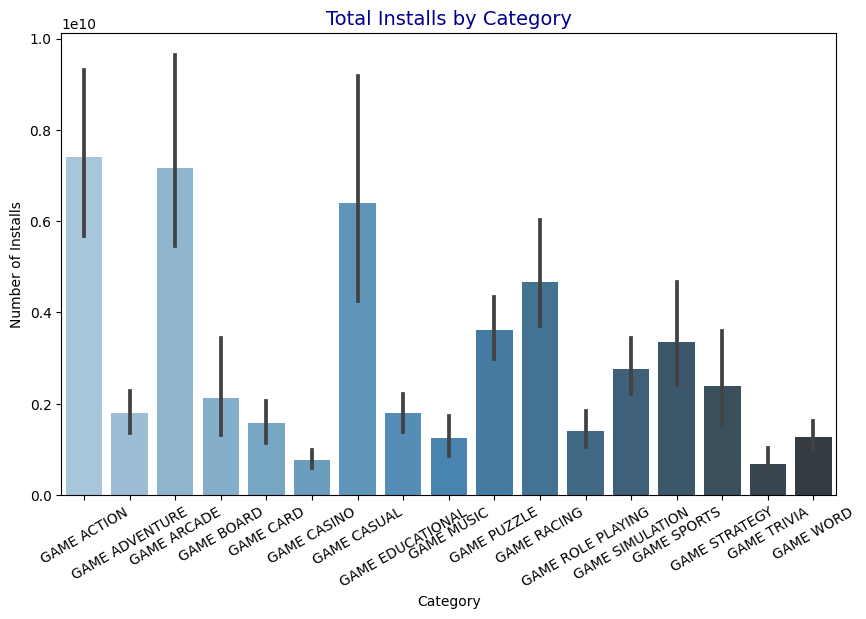

In [20]:
def convert_install_value(x):
    if pd.isna(x):
        return 0
    x = str(x).replace(',', '').strip()
    if 'K' in x:
        return float(x.replace('K', '')) * 1_000
    elif 'M' in x:
        return float(x.replace('M', '')) * 1_000_000
    elif 'B' in x:
        return float(x.replace('B', '')) * 1_000_000_000
    else:
        try:
            return float(x)
        except:
            return 0
numeric_cols = [
    'total ratings', 'installs', 'average rating',
    'growth (30 days)', 'growth (60 days)', 'price',
    '5 star ratings', '4 star ratings', '3 star ratings',
    '2 star ratings', '1 star ratings'
]

for col in numeric_cols:
    df[col] = df[col].apply(convert_install_value)

# ✅ Confirm numeric types
print(df[numeric_cols].dtypes)
plt.figure(figsize=(10,6))
sns.barplot(x='category', y='installs', data=df, estimator=sum, palette='Blues_d')
plt.title('Total Installs by Category', fontsize=14, color='darkblue')
plt.xlabel('Category')
plt.ylabel('Number of Installs')
plt.xticks(rotation=30)
plt.show()

## ML Algorithms

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [22]:
def convert_number(x):
    if pd.isna(x):
        return 0
    x = str(x).replace(',', '').strip()
    if 'K' in x:
        return float(x.replace('K', '')) * 1_000
    elif 'M' in x:
        return float(x.replace('M', '')) * 1_000_000
    else:
        try:
            return float(x)
        except:
            return 0

numeric_cols = [
    'total ratings', 'installs', 'average rating',
    'growth (30 days)', 'growth (60 days)', 'price',
    '5 star ratings', '4 star ratings', '3 star ratings',
    '2 star ratings', '1 star ratings'
]
for col in numeric_cols:
    df[col] = df[col].apply(convert_number)

In [23]:
le = LabelEncoder()
df['category'] = le.fit_transform(df['category'])
df['paid'] = le.fit_transform(df['paid'])  # Yes=1, No=0

In [24]:
X = df.drop(columns=['title', 'paid'])
y = df['paid']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = acc
    print(f"{name}: {acc:.2f}%")

Logistic Regression: 99.61%
Decision Tree: 100.00%
Random Forest: 99.81%
Support Vector Machine: 99.81%
Naive Bayes: 30.44%
K-Nearest Neighbors: 99.81%


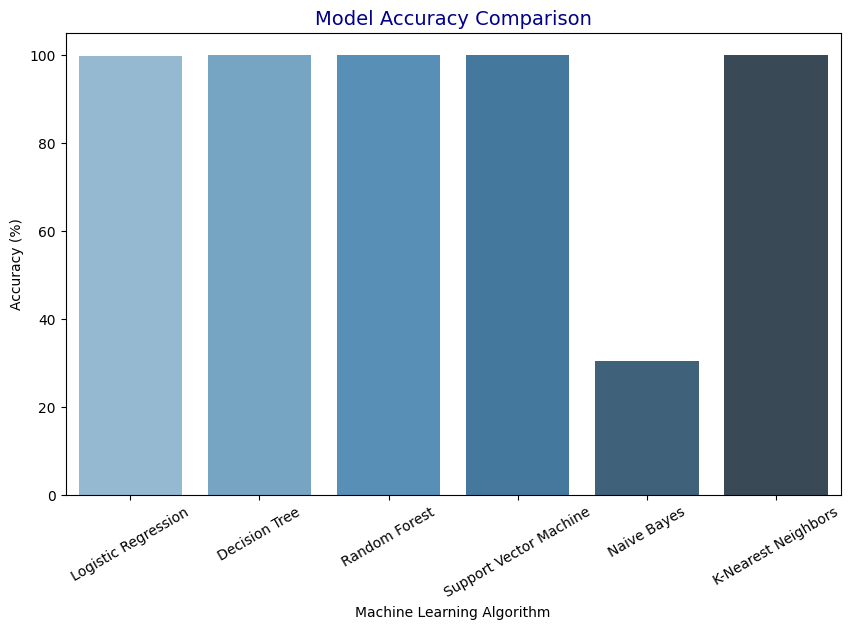

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='Blues_d')
plt.title('Model Accuracy Comparison', fontsize=14, color='darkblue')
plt.xlabel('Machine Learning Algorithm')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30)
plt.show()

## thank you...pls upvote!!